In [ ]:
# Simulate the collisions between particles
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from itertools import combinations
# import the needed functions
from functions import ToroidalCoil
from functions import PoloidalLoop
from functions import MagneticVector
from functions import RK4mod

In [ ]:
# Define parameters and initial values
a = 1
b = 0.5
test_r = np.array([0, -(a + 0.2), 0])
test_v = np.array([np.random.uniform(0.03, 0.12), -np.random.uniform(0.03, 0.12), -np.random.uniform(0.03, 0.12)])
test_pos = np.concatenate((test_r, test_v))

# Create troidal loop
loop_tor = ToroidalCoil(20)
sym_loop_tor = loop_tor[0]
ploop_tor = loop_tor[1]
# Create plasma current loop
loop_plasma = PoloidalLoop(a, 0)
sym_loop_plasma = loop_plasma[0]
ploop_plasma = loop_plasma[1]

# Define Lorentz force
def Lorentz(t, pos):
    # Constants
    qm = 1
    # Separate position array
    r = pos[0:3]
    v = pos[3:6]

    # Calculate fields
    field_tor = MagneticVector(sym_loop_tor, r)
    field_plasma = MagneticVector(sym_loop_plasma, r)

    B = 0.5*field_tor + 1*field_plasma 
    Bnorm = np.sqrt(B[0]**2 + B[1]**2 + B[2]**2)

    # Calculate acceleration
    a = qm*(np.cross(v, B))

    # No acceleration, particles move along the field lines 
    # vnorm = np.sqrt(v[0]**2 + v[1]**2 + v[2]**3)
    # v = 1*vnorm*(B/Bnorm) 
    # a = np.array([0,0,0])

    # Organize output
    out = np.concatenate((v, a))
    return out


# Test
a_test = Lorentz(0, test_pos)
print(6e-5*2)

0.00012


c:\Users\JUAN\Downloads\projects\functions.py:120: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  X = sci.integrate.quad(dBxdv, a, b, args=(x, y, z))[0]
c:\Users\JUAN\Downloads\projects\functions.py:121: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
 

In [ ]:
# Create  particle class 
class Particle:
    # Initialize
    def __init__ (self, init, radius=3e-2):
        self.r = np.array([init[0:3]])
        self.v = np.array([init[3:6]])
        self.radius = radius


    # Check overlaps
    def overlaps(self, other):
        return np.linalg.norm(self.r - other.r) < self.radius + other.radius

    # Advance position of the particle
    def advance(self, dt):
        pos = np.concatenate((self.r[-1], self.v[-1]))
        next_pos = pos + dt*RK4mod(Lorentz, dt, pos)
        next_r = np.array([next_pos[0:3]])
        self.r = np.append(self.r, next_r, axis=0)
        next_v = np.array([next_pos[3:6]])
        self.v = np.append(self.v, next_v, axis=0)


# Create simulation class
class Simulation:
    # Initialize simulation
    def __init__(self, n):
        self.init_particles(n)
    
    # Create n particles
    def init_particles(self, n):
        self.n = n
        self.particles = []
        r_top_lim = 0.1
        v_top_lim = 0.2
        a = 1
        b = 0.5
        for i in range(n):
            # Random positions and velocities
            # r = np.array([0, -(a + 0.2), 0]) + np.array([0, -np.random.uniform(0, r_top_lim), 0])
            r = np.array([0, -(a + 0.2), 0]) + np.random.uniform(0, r_top_lim, (3))
            v = np.array([0.3, -0.3, -0.3]) + np.random.uniform(0, v_top_lim, (3))
            pos = np.concatenate((r, v))
            # Create particle
            particle = Particle(pos)
            # Put it in particle list
            self.particles.append(particle)

    # Collissions
    # particles only collide when they come into contact
    def contact_colission(self):
        # Change velocities like elastic collision
        def change_vel(p1, p2):
            m1 = 1
            m2 = m1
            M = m1 + m2
            r1, r2 = p1.r[-1], p2.r[-1]
            d = r1**2 + r2**2
            v1, v2 = p1.v[-1], p2.v[-1]
            u1 = v1 - 2*m2 / M * np.dot(v1-v2, r1-r2) / d * (r1 - r2)
            u2 = v2 - 2*m1 / M * np.dot(v2-v1, r2-r1) / d * (r2 - r1)
            p1.v = np.append(p1.v, np.array([1*u1]), axis=0)
            p2.v = np.append(p2.v, np.array([1*u2]), axis=0)

        # Generate pairs
        pairs = combinations(range(self.n), 2)
        for i, j in pairs:
            # Check if particles actually overlap
            if self.particles[i].overlaps(self.particles[j]):
                change_vel(self.particles[i], self.particles[j])
                # print('collision')

        
    # particles collide with a certain frequency
    def frequency_collision(self):
        # Change velocities like hard ball colissions
        def change_vel_col(p1):
            # Mass of particle
            m = 1
            # Parameters scattered particle
            r = p1.r[-1]
            v = p1.v[-1]
            vnorm = np.sqrt(v[0]**2 + v[1]**2 + v[2]**2)
            vdir = v/vnorm
            print('vnorm = '+str(vnorm))
            # Velocity of the overall flow of partilces 
            # speed is average between min and max vel of created particles
            vflownorm = np.sqrt(3*0.4**2)
            print('vflownorm = '+str(vflownorm))
            # Flow vector, in the same direction as field
            vflow = vflownorm*vdir
            # Projection of flow vector unto particle velocity
            vprl = np.dot(vflow, v)/vnorm
            # Change in direction of scattered particles
            # Azimuthal is random between 0 and 2pi because of azimuthal symmetry
            phi = np.random.uniform(0, 2*np.pi)
            # Scattering angle theta is function of impact parameter ratio (Lambda)
            # Lambda is random from 0 to 10^8, but is limited to 5 to make collisions more visible
            Lambda = np.random.uniform(0, 5)
            theta = -2*np.arctan(Lambda) + np.pi
            # Smaller theta for the deviations
            # stheta = np.random.uniform(0, np.pi/4)
            # Change in momentum norm of collided particle
            Dmv = m*(vnorm - vprl)*(1 - np.cos(theta))
            # Resulting speed of the particle
            vfnorm = vnorm - Dmv/m
            # Change in velocty
            Dv = vfnorm*np.array([np.cos(theta), np.sin(theta)*np.sin(phi), np.sin(theta)*np.cos(phi)])
            # with smaller theta
            # Dv = vfnorm*np.array([np.cos(stheta), np.sin(stheta)*np.sin(phi), np.sin(stheta)*np.cos(phi)])
            # Final velocity of scattered particle
            # Direction
            vfi = v + Dv
            vfdir = vfi/(np.sqrt(vfi[0]**2 + vfi[1]**2 + vfi[2]**2))
            vf = vfnorm*vfdir
            # Append it to the velocity array
            p1.v = np.append(p1.v, np.array([1*vf]), axis=0)

        # Collision all the particles
        for particle in self.particles:
            # print("collision")
            change_vel_col(particle)



    # Run simulation
    def run(self, tf, dt):
        self.tn = int(tf/dt)
        t = np.linspace(0, tf, self.tn)
        # Colission counter for frequency
        c = 0
        # Run through time
        for ts in t:
            # Run through particles
            for particle in self.particles:
                # Advance particle
                particle.advance(dt)
            # Check and manage colissions
            self.frequency_collision()
            # Do collisions every with a ceratain frequency
            if c % 4 == 0:
                self.collide()
            # Update counter
            c += 1

    # Make graph of position
    def paint(self):
        # Parameters
        a = 1
        b = 0.5
        # Create axis
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        # Create weights for cmap 
        weights = np.linspace(0, 1, self.tn+1)
        # Go through particles
        for particle in self.particles:
            x = particle.r[:, 0]
            y = particle.r[:, 1]
            z = particle.r[:, 2]
            ax.scatter(x, y, z, c=weights, cmap='plasma')
            ax.plot(x, y, z, c='gray', alpha=0.6)
        # aspect ratio
        ax.set_xlim(-b-a,b+a) 
        ax.set_ylim(-b-a,b+a)
        ax.set_zlim(-b-a,b+a) 
        ax.axis('off')
        # Things to be able to put colorbar, with no numbers and label
        cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 1), cmap='plasma'),ax=ax)
        cbar.set_ticks([])
        cbar.set_label('Time')
        # Custom legend
        patch = mpatches.Patch(color='grey', label='Position of particles')
        plt.legend(handles=[patch])

    # Make velocity graph
    def paint_vel(self):
        # Parameters
        a = 1
        b = 0.5
        # Create axis
        fig = plt.figure()
        ax = fig.add_subplot(111)
        # Go through particles
        for particle in self.particles:
            vx = particle.v[:, 0]
            vy = particle.v[:, 1]
            vz = particle.v[:, 2]
            vnorm = np.sqrt(vx**2 + vy**2 + vz**2)
            xlins = np.linspace(0,1, len(vnorm))
            ax.scatter(xlins, vnorm)
            ax.plot(xlins, vnorm)
        # linspace for the x axis
        lins = np.linspace(0, 1, len(self.particles[0].v[:, 0]))
        # velocity of the background flow, the same as in the sim
        vflow = np.sqrt(3*(0.4**2))
        # make line for it
        ax.plot(lins, np.full(len(lins), vflow), label='Ion average speed', c='black')

        # no numbers on axis
        ax.set_xticklabels([])
        # ax.set_yticklabels([])

        # labels
        ax.set_xlabel('Time')
        ax.set_ylabel('Particle speed')

        plt.legend()

In [ ]:
# Simulation parameters
n = 10
tf = 5
dt = 0.1

# Create simulation
sim = Simulation(n)
# Run simulation
sim.run(tf, dt)

c:\Users\JUAN\Downloads\projects\functions.py:121: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  Y = sci.integrate.quad(dBydv, a, b, args=(x, y, z))[0]
c:\Users\JUAN\Downloads\projects\functions.py:120: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  X = sci.integrate.quad(dBxdv, a, b, args=(x, y, z))[0]


#####
#####
#####
DONE
#####
#####
#####


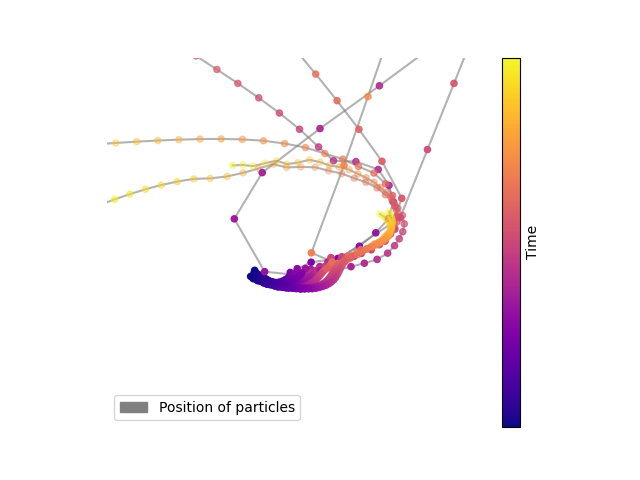

In [ ]:
# plot the position of the particles
%matplotlib widget
sim.paint()

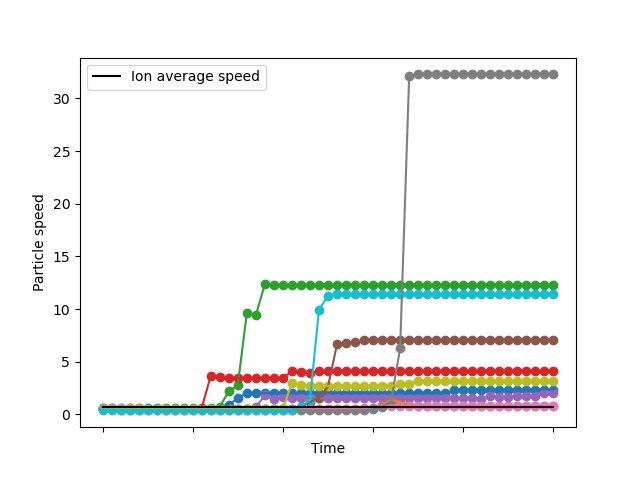

In [ ]:
# plot the velocity of the particles
sim.paint_vel()